# Assignment: ANN Salary Regression

Use the same `Churn_Modelling.csv` dataset, but change the target to `EstimatedSalary`. Your goal is to practice how an ANN changes when the task changes from classification to regression.

## Required Changes
- Target: `EstimatedSalary`
- Remove `EstimatedSalary` from input features
- Output layer: 1 neuron with **linear** activation
- Loss: choose `mse` or `mae` and explain your choice
- Evaluation: MAE, RMSE and R2
- Save the model in `.keras` format
- Build and deploy a Streamlit salary prediction app

## Step 1 - Imports

In [3]:
# Write your imports here
import os  ## opersing system module run time m helo krta h 
import pickle  # train model ko kam space m save krta h ..(file ko load krna chlana bht helpful krta h heay load ko call krna) 
import datetime  # current date time k liye 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler 
from sklearn.metrics import(
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score
)
import tensorflow as tf

print("Tensor flow: ",tf.__version__)
from tensorflow import keras




Tensor flow:  2.21.0


## Step 2 - Load and inspect the dataset

In [4]:
data = pd.read_csv('Churn_Modelling.csv')
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Step 3 - EDA and data quality checks

In [5]:
# shape, info, describe, missing values, duplicates, salary distribution
print("shape:", data.shape)


shape: (10000, 14)


In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.2 MB


In [7]:
data.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [8]:
print("Missing value: ", data.isnull().sum())
print("\nduplicated Rows: ", data.duplicated().sum())

Missing value:  RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

duplicated Rows:  0


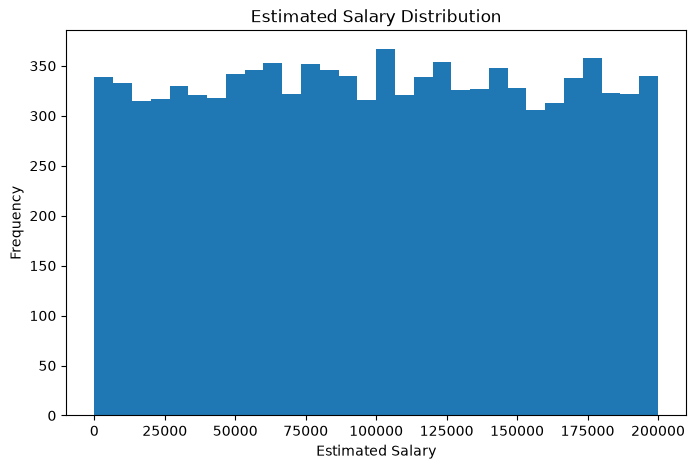

In [9]:
plt.figure(figsize=(8, 5))

plt.hist(data["EstimatedSalary"], bins=30)

plt.xlabel("Estimated Salary")
plt.ylabel("Frequency")
plt.title("Estimated Salary Distribution")

plt.show()

## Step 4 - Define X and y

In [10]:
model_data=data.drop(columns=["RowNumber", "CustomerId", "Surname"]).copy()
model_data.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [11]:
# y = EstimatedSalary
# X = remaining useful features
X=model_data.drop(columns=["EstimatedSalary", "Exited"])
y=model_data["EstimatedSalary"]

In [12]:
X.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember
0,619,France,Female,42,2,0.00,1,1,1
1,608,Spain,Female,41,1,83807.86,1,0,1
2,502,France,Female,42,8,159660.80,3,1,0
3,699,France,Female,39,1,0.00,2,0,0
4,850,Spain,Female,43,2,125510.82,1,1,1


In [13]:
y.head()

0    101348.88
1    112542.58
2    113931.57
3     93826.63
4     79084.10
Name: EstimatedSalary, dtype: float64

## Step 5 - Train-test split and preprocessing

In [14]:
# Fit encoders and scaler on training data only
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y, 
    test_size=0.20, 
    random_state=42, 
)


In [15]:
gender_encoder=OrdinalEncoder(handle_unknown='use_encoded_value',unknown_value=-1)

gender_encoder.fit(X_train_raw[["Gender"]])    ## yhn num

print('Gender categories : ', gender_encoder.categories_)

geography_encoder = OneHotEncoder(handle_unknown='ignore',sparse_output=False)

geography_encoder.fit(X_train_raw[['Geography']]) ## yhn number assign nh ho rhe y srf categories seekha rha h 

print('Geography :', geography_encoder.categories_)


Gender categories :  [array(['Female', 'Male'], dtype=object)]
Geography : [array(['France', 'Germany', 'Spain'], dtype=object)]


In [16]:
def encode_features(df):
    df=df.copy()
    df['Gender']=gender_encoder.transform(df[['Gender']]).ravel()  ## yhn aravel one dimension m kr rha 0,1 m  

    geo_array=geography_encoder.transform(df[['Geography']]) ## yhn hum sb ko alg alg kr rhe h jese france 1 baki 0 then next m spain 1 baki 0 and so on 
    geo_columns=geography_encoder.get_feature_names_out(['Geography']) ## yhn hum columns k name de rhe 
    geo_df=pd.DataFrame(geo_array,columns=geo_columns,index=df.index)## ab jo humne tble bnaya usko data frame m bna rhe 

    df=pd.concat([df.drop(columns='Geography'),geo_df],axis=1)## yhn hum apne real data m us data frame ko add kr rhe jo humne uper bnaya 

    return df

In [17]:
X_train_encoded=encode_features(X_train_raw)
X_test_encoded=encode_features(X_test_raw)

print("Final Feature Count: ",X_train_encoded.shape[1])
X_train_encoded.head(5)

Final Feature Count:  11


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,Geography_France,Geography_Germany,Geography_Spain
9254,686,1.0,32,6,0.00,2,1,1,1.0,0.0,0.0
1561,632,1.0,42,4,119624.60,2,1,1,0.0,1.0,0.0
1670,559,1.0,24,3,114739.92,1,1,0,0.0,0.0,1.0
6087,561,0.0,27,9,135637.00,1,1,0,1.0,0.0,0.0
6669,517,1.0,56,9,142147.32,1,0,0,1.0,0.0,0.0


In [18]:
X_test_encoded.head(
)

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,Geography_France,Geography_Germany,Geography_Spain
6252,596,1.0,32,3,96709.07,2,0,0,0.0,1.0,0.0
4684,623,1.0,43,1,0.00,2,1,1,1.0,0.0,0.0
1731,601,0.0,44,4,0.00,2,1,0,0.0,0.0,1.0
4742,506,1.0,59,8,119152.10,2,1,1,0.0,1.0,0.0
4521,560,0.0,27,7,124995.98,1,1,1,0.0,0.0,1.0


In [19]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train_encoded)
X_test=scaler.transform(X_test_encoded)

## Step 6 - Build a regression ANN

In [39]:
model = keras.Sequential([
    keras.Input(shape=(X_train.shape[1],)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1, activation='linear')
])

## Step 7 - Compile and train

In [21]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

In [22]:
# optimizer=Adam, loss='mse' or 'mae', include a suitable regression metric
optimizer = keras.optimizers.Adam(learning_rate=0.001)
model.compile(
    optimizer='adam',     # Model ke weights ko update karta hai taake prediction errors gradually kam hon.
    loss='mse',      #Model ki prediction aur actual salary ke difference ko measure karta hai.   MSE = Mean Squared Error.
    metrics=['mae']  #Training ke dauran MAE bhi show karega, jo samajhna easy hai because ye salary units mein error batata hai
)




In [23]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.20,
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping]
)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 13306720256.0000 - mae: 99970.8516 - val_loss: 13692085248.0000 - val_mae: 102009.8672
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 13225817088.0000 - mae: 99566.5781 - val_loss: 13527761920.0000 - val_mae: 101207.7578
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 12941327360.0000 - mae: 98150.7578 - val_loss: 13096268800.0000 - val_mae: 99102.0938
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 12350185472.0000 - mae: 95220.1094 - val_loss: 12321114112.0000 - val_mae: 95304.8281
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 11413123072.0000 - mae: 90568.0078 - val_loss: 11199278080.0000 - val_mae: 89758.0625
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 10169567232.0000 - mae: 84385.6094 - val_loss: 9809966080.0000 - val_mae: 82835.2812
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 8730996736.0000 - mae: 77131.3125 - val_loss: 8287649280

EARLY STOPPING METHOD 

## Step 8 - Evaluate

In [24]:
# Calculate MAE, RMSE and R2 on the untouched test set
test_pred = model.predict(X_test).ravel()

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [32]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, test_pred)

rmse = np.sqrt(mean_squared_error(y_test, test_pred))

r2 = r2_score(y_test, test_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 50099.18393546875
RMSE: 57918.400561740295
R²: -0.016141702764651544


MAE (Mean Absolute Error): Average difference between actual salary and predicted salary.
RMSE (Root Mean Squared Error): Similar to MAE, but gives more importance to large errors.
R² (R-squared): Shows how well the model explains the variation in salary values.

## Step 9 - Save and reload model

In [33]:
# model.save('salary_model.keras')
model.save("salary_model.keras")

In [34]:
loaded_model = keras.models.load_model("salary_model.keras")

In [36]:
loaded_pred = loaded_model.predict(X_test).ravel()

print(loaded_pred[:5])

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
[ 89587.37  96413.71  97344.46 101835.76 100902.99]


FILES GENERATE USING PICKLE 


In [37]:
# Save salary model's Gender encoder
with open("salary_gender_encoder.pkl", "wb") as f:
    pickle.dump(gender_encoder, f)

# Save salary model's Geography encoder
with open("salary_geography_encoder.pkl", "wb") as f:
    pickle.dump(geography_encoder, f)

# Save salary model's scaler
with open("salary_scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("Salary preprocessing files saved successfully!")

Salary preprocessing files saved successfully!


PREDICT NEW EXAMPLES 

In [42]:
new_customers = pd.DataFrame({
    'CreditScore': [650, 750, 580, 820, 700],
    'Geography': ['France', 'Spain', 'Germany', 'France', 'Spain'],
    'Gender': ['Male', 'Female', 'Male', 'Female', 'Male'],
    'Age': [35, 45, 29, 52, 38],
    'Tenure': [5, 7, 3, 8, 4],
    'Balance': [75000, 120000, 45000, 150000, 85000],
    'NumOfProducts': [2, 1, 1, 2, 2],
    'HasCrCard': [1, 1, 0, 1, 1],
    'IsActiveMember': [1, 0, 1, 1, 0]
})

# here we applying same processing 
new_customers_encoded = encode_features(new_customers)

new_customers_scaled = scaler.transform(
    new_customers_encoded
)
# predict Salaries
new_salary_pred = loaded_model.predict(
    new_customers_scaled
).ravel()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step


In [43]:
#Display resukts 
for i, salary in enumerate(new_salary_pred):
    print(
        f"Customer {i+1}: "
        f"Predicted Salary = {salary:,.2f}"
    )

Customer 1: Predicted Salary = 95,290.30
Customer 2: Predicted Salary = 99,956.02
Customer 3: Predicted Salary = 82,944.93
Customer 4: Predicted Salary = 99,128.78
Customer 5: Predicted Salary = 89,308.91


## Step 10 - Streamlit deployment

In [47]:
# Build app.py, requirements.txt and deploy on Streamlit Community Cloud

#build in .py file 

## Reflection Questions
1. Why did we remove sigmoid from the output layer?
2. Why is Binary Cross-Entropy not suitable here?
3. What does MAE mean in salary units?
4. If RMSE is much larger than MAE, what might that suggest?
5. What are the limitations of predicting salary from this classroom dataset?

ANSWER 1:

We removed sigmoid because salary prediction is a regression problem. Salary can have a wide range of continuous values, while sigmoid restricts the output between 0 and 1. A linear output layer can predict any suitable salary value.

ANSWER 2:

Binary Cross-Entropy is designed for binary classification, where the target has values such as 0 or 1. Our target is EstimatedSalary, which is a continuous numerical value. Therefore, regression losses such as MSE or MAE are more suitable.

ANSWER 3:

MAE (Mean Absolute Error) represents the average absolute difference between the predicted salary and the actual salary, in the same currency units as the salary.

For example, if MAE = 10,000, the model's predictions are off by about 10,000 salary units on average.

ANSWER 4:

It may suggest that the model has some large prediction errors or outliers. RMSE gives more importance to large errors because it squares them, while MAE treats errors more evenly.

ANSWER 5:

The dataset has limited features and may not represent real-world salary factors. Important factors such as education, job title, skills, experience, industry, location, and company size may be missing. Therefore, the model's predictions should mainly be considered a classroom exercise, not a reliable real-world salary estimator.